# Polynomial Kernel SVMs and the Geometry of Lifted Decision Boundaries
## M508: Mathematics for Machine Learning — Starter Notebook

This notebook accompanies the guided project document. It provides:

- **Shared utilities** (Cells 1–2): dataset generators, plotting functions, and model-fitting helpers that you will use throughout.
- **Dataset 1 (XOR):** a fully worked example showing the complete workflow — data generation, convex hulls, degree sweep, and support vector analysis. Study this section to understand the tools and the style of analysis expected.
- **Dataset 2 (Crescents):** scaffolded cells with instructions. The data generator is provided; you write the fitting, plotting, and comparison code.
- **Dataset 3 (Fragmented Clusters):** scaffolded cells with instructions. The data generator is provided; you write the fitting, plotting, and comparison code.

**Conventions**
- Polynomial kernel: $k(\mathbf{x},\mathbf{y})=(\mathbf{x}^T \mathbf{y} + c)^d$ with offset $c=1$ in all dataset experiments.
- Models are fit using a pipeline: `StandardScaler` $\to$ `SVC(kernel='poly', gamma='scale')`.
- Decision boundaries and margins are visualized in $\mathbb{R}^2$ by evaluating the fitted classifier on a dense grid.

Run Cells 1 and 2 first to load all utilities, then work through each section in order.

In [1]:
# Cell 1 — Imports, reproducibility, dataset generators, and core utilities
# Run this cell first.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from scipy.spatial import ConvexHull
import pandas as pd
import itertools
import warnings
warnings.filterwarnings("ignore")

RNG = 0
np.random.seed(RNG)

# ── Dataset generators ─────────────────────────────────────────

def make_xor(n_per_cluster=60, gap=1.4, scale=1.0, random_state=None):
    """Four clusters at corners of a square; diagonally opposite
    clusters share a label.  Not linearly separable."""
    rs = np.random.RandomState(random_state)
    centers = np.array([[1,1],[1,-1],[-1,1],[-1,-1]]) * gap * scale
    X, y = [], []
    for i, c in enumerate(centers):
        X.append(rs.randn(n_per_cluster, 2) * 0.25 + c)
        y.append(np.full(n_per_cluster, 0 if i in (0, 3) else 1))
    return np.vstack(X), np.concatenate(y)

def make_crescents(n_samples=400, noise=0.12, random_state=None):
    """Two interlocking half-moon classes."""
    return make_moons(n_samples=n_samples, noise=noise, random_state=random_state)

def make_fragmented(n_per_cluster=25, random_state=None):
    """Ten clusters with fixed centers in a staggered grid.
    Adjacent clusters have opposite labels, creating a boundary
    that no single low-degree algebraic curve can describe."""
    centers = np.array([
        [-1.8,  1.8], [-0.3,  1.8], [ 1.2,  1.8],
        [-1.0,  0.3], [ 0.5,  0.3], [ 2.0,  0.3],
        [-1.8, -1.2], [-0.3, -1.2], [ 1.2, -1.2], [ 2.0, -1.2],
    ])
    rs = np.random.RandomState(random_state)
    X_list, y_list = [], []
    for i, c in enumerate(centers):
        X_list.append(rs.randn(n_per_cluster, 2) * 0.35 + c)
        y_list.append(np.full(n_per_cluster, i % 2))
    return np.vstack(X_list), np.concatenate(y_list)

# ── Plotting utilities ─────────────────────────────────────────

def plot_data(ax, X, y, title=None):
    """Scatter plot of labelled 2-D data."""
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr',
               edgecolor='k', s=30, alpha=0.7)
    if title:
        ax.set_title(title)
    ax.set_aspect('equal', 'box')

def plot_convex_hulls(ax, X, y):
    """Overlay the convex hull of each class."""
    colors = ['tab:blue', 'tab:red']
    for label in np.unique(y):
        pts = X[y == label]
        hull = ConvexHull(pts)
        verts = pts[hull.vertices]
        ax.fill(verts[:, 0], verts[:, 1], alpha=0.15, color=colors[label])
        ax.plot(np.r_[verts[:, 0], verts[0, 0]],
                np.r_[verts[:, 1], verts[0, 1]],
                linewidth=1.5, color=colors[label])

def plot_boundary_and_margin(ax, clf, X, y, title=None, grid_resolution=300):
    """Decision regions (shaded), decision boundary (solid),
    and margin curves (dashed) for a fitted pipeline."""
    pad = 1.0
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_resolution),
                         np.linspace(y_min, y_max, grid_resolution))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(grid).reshape(xx.shape)
    D = clf.decision_function(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.18, cmap='bwr')
    ax.contour(xx, yy, D, levels=[-1, 0, 1], colors='k',
               linestyles=['--', '-', '--'], linewidths=[0.8, 1.4, 0.8])
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr',
               edgecolor='k', s=25, alpha=0.7)
    if title:
        ax.set_title(title, fontsize=10)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal', 'box')

def plot_support_vectors(ax, clf, X, y, title=None):
    """Decision boundary plot with support vectors circled."""
    plot_boundary_and_margin(ax, clf, X, y, title=title)
    scaler = clf.named_steps['standardscaler']
    svc = clf.named_steps['svc']
    sv = scaler.inverse_transform(svc.support_vectors_)
    ax.scatter(sv[:, 0], sv[:, 1], facecolors='none',
               edgecolors='k', s=120, linewidths=2)

# ── Model fitting and grid search ─────────────────────────────

def fit_poly_svm(X, y, degree=2, C=1.0, coef0=1.0, cv=5):
    """Fit StandardScaler -> poly-kernel SVC.  Returns a dict with
    the fitted pipeline, training accuracy, 5-fold CV accuracy,
    and support vector count."""
    clf = make_pipeline(StandardScaler(),
                        SVC(kernel='poly', degree=degree, C=C,
                            coef0=coef0, gamma='scale'))
    clf.fit(X, y)
    svc = clf.named_steps['svc']
    cv_scores = cross_val_score(
        clf, X, y,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=RNG))
    return {
        'pipeline': clf,
        'svc': svc,
        'train_acc': accuracy_score(y, clf.predict(X)),
        'cv_acc_mean': cv_scores.mean(),
        'cv_acc_std': cv_scores.std(),
        'n_support': svc.n_support_.sum(),
    }

def run_grid(X, y, degrees, Cs, coef0=1.0, cv=5):
    """Fit polynomial SVMs over a (degree, C) grid.
    Returns a DataFrame with accuracies and support vector counts."""
    rows = []
    for d, C in itertools.product(degrees, Cs):
        res = fit_poly_svm(X, y, degree=d, C=C, coef0=coef0, cv=cv)
        rows.append({
            'degree': d, 'C': C,
            'train_acc': res['train_acc'],
            'cv_acc': res['cv_acc_mean'],
            'cv_std': res['cv_acc_std'],
            'n_support': res['n_support'],
        })
    return pd.DataFrame(rows)

# ── Feature-map helpers (Section 1) ────────────────────────────

def n_monomials_exact_degree(d):
    """Monomials in two variables of total degree exactly d."""
    return d + 1

def n_monomials_degree_leq(d):
    """Monomials in two variables of total degree <= d."""
    return (d + 1) * (d + 2) // 2

print("All utilities loaded.")

All utilities loaded.


In [2]:
# Cell 2 — Feature map implementations for Section 1 verification

def phi_degree2_c0(x):
    """Degree-2, c=0 feature map: R^2 -> R^3.
    phi(x1,x2) = (x1^2, sqrt(2)*x1*x2, x2^2)."""
    x1, x2 = x[..., 0], x[..., 1]
    return np.stack([x1**2, np.sqrt(2)*x1*x2, x2**2], axis=-1)

def phi_degree2_cpos(x, c=1.0):
    """Degree-2, c>0 feature map: R^2 -> R^6.
    phi_c(x) = (x1^2, sqrt(2)*x1*x2, x2^2, sqrt(2c)*x1, sqrt(2c)*x2, c).
    Satisfies (x^T y + c)^2 = phi_c(x)^T phi_c(y)."""
    x1, x2 = x[..., 0], x[..., 1]
    return np.stack([
        x1**2,
        np.sqrt(2)*x1*x2,
        x2**2,
        np.sqrt(2*c)*x1,
        np.sqrt(2*c)*x2,
        np.full_like(x1, c),
    ], axis=-1)

---
## 1  Mathematical Background

### Problem 1

See the project document for the full problem statement.

*Your written solutions to Problem 1 go in your report, not in this notebook.
The cells below let you verify your feature maps numerically.*

In [3]:
# Verify Problem 1(a): d=2, c=0 feature map
rs = np.random.RandomState(RNG)
x = rs.randn(5, 2)
y_pts = rs.randn(5, 2)

K_direct = (x @ y_pts.T)**2
K_phi = phi_degree2_c0(x) @ phi_degree2_c0(y_pts).T
print("Problem 1(a) verification")
print("max |(x^T y)^2 - phi(x)^T phi(y)| =", np.max(np.abs(K_direct - K_phi)))

Problem 1(a) verification
max |(x^T y)^2 - phi(x)^T phi(y)| = 1.7763568394002505e-15


In [4]:
# Verify Problem 1(b): d=2, c>0 feature map
c_val = 1.0
K_direct_c = (x @ y_pts.T + c_val)**2
K_phi_c = phi_degree2_cpos(x, c=c_val) @ phi_degree2_cpos(y_pts, c=c_val).T
print("Problem 1(b) verification  (c = 1)")
print("max |(x^T y + c)^2 - phi_c(x)^T phi_c(y)| =", np.max(np.abs(K_direct_c - K_phi_c)))

Problem 1(b) verification  (c = 1)
max |(x^T y + c)^2 - phi_c(x)^T phi_c(y)| = 3.552713678800501e-15


### Problem 2

See the project document for the full problem statement.

*Your written solutions go in your report.  The cell below computes the monomial counts for reference.*

In [5]:
# Problem 2(a): monomial counts in two variables
print("Monomial counts (two variables):")
print(f"{'d':>3s}  {'exact deg d':>12s}  {'deg <= d':>8s}")
print("-" * 28)
for d in [1, 2, 3, 5, 8, 10]:
    print(f"{d:3d}  {n_monomials_exact_degree(d):12d}  {n_monomials_degree_leq(d):8d}")

Monomial counts (two variables):
  d   exact deg d  deg <= d
----------------------------
  1             2         3
  2             3         6
  3             4        10
  5             6        21
  8             9        45
 10            11        66


---
## 2  Dataset 1: XOR Pattern — Worked Example

This section is **fully worked** to demonstrate the analysis workflow.
Study it carefully — you will reproduce this workflow for Datasets 2 and 3.

### Problem 3 (Before fitting)

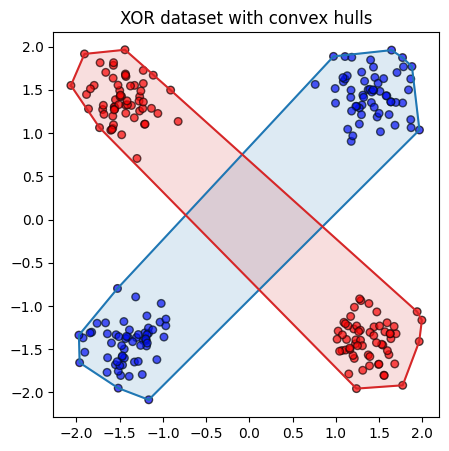

In [6]:
# Generate the XOR dataset
X_xor, y_xor = make_xor(n_per_cluster=60, gap=1.4, scale=1.0, random_state=RNG)

# Problem 3(a): display with convex hulls
fig, ax = plt.subplots(figsize=(5, 5))
plot_data(ax, X_xor, y_xor, title="XOR dataset with convex hulls")
plot_convex_hulls(ax, X_xor, y_xor)
plt.show()

*Problem 3(b)–(c): Write your predictions in your report before looking at the fits below.*

### Problem 4 (Fitting and observation)

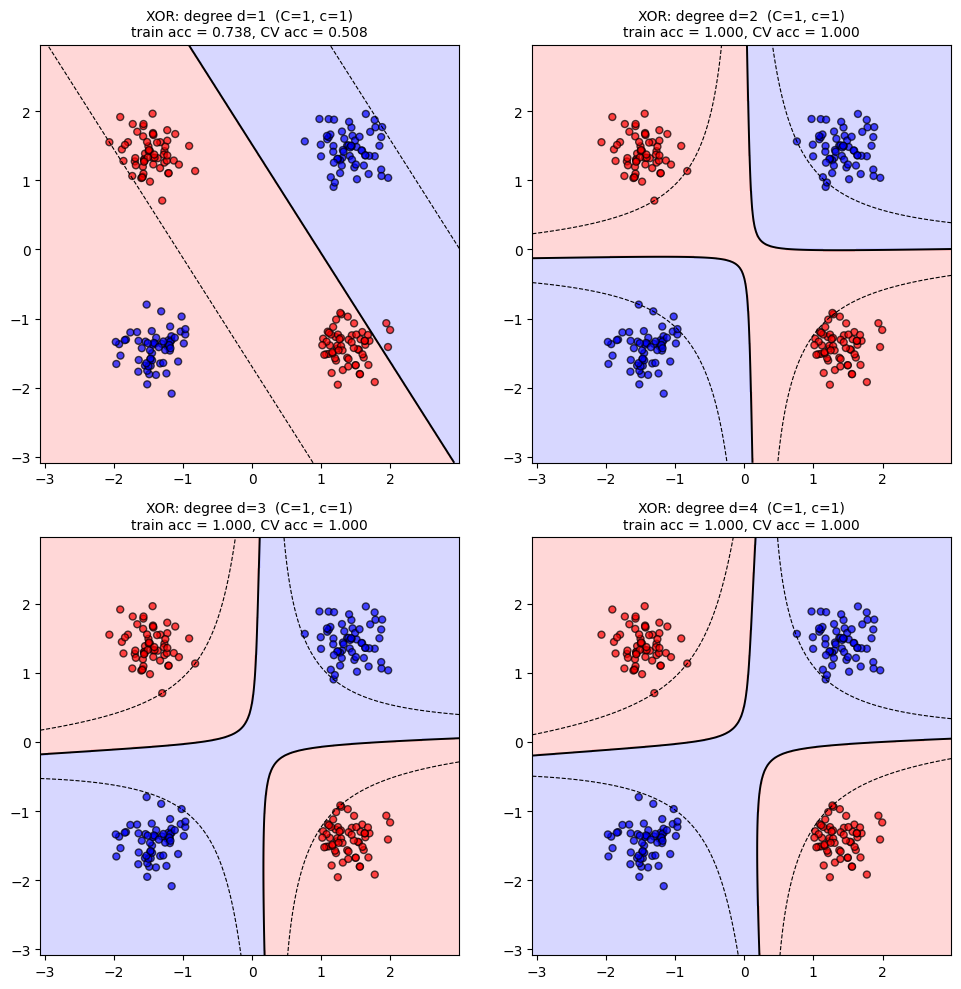

Degrees with perfect training separation: [2, 3, 4]


In [7]:
# Problem 4: fit polynomial kernel SVMs with c=1, degrees 1-4
degrees_xor = [1, 2, 3, 4]
models_xor = {}

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, d in zip(axes.ravel(), degrees_xor):
    res = fit_poly_svm(X_xor, y_xor, degree=d, C=1.0, coef0=1.0)
    models_xor[d] = res
    title = (f"XOR: degree d={d}  (C=1, c=1)\n"
             f"train acc = {res['train_acc']:.3f}, "
             f"CV acc = {res['cv_acc_mean']:.3f}")
    plot_boundary_and_margin(ax, res['pipeline'], X_xor, y_xor, title=title)

plt.tight_layout()
plt.show()

# Identify degrees with (near) perfect training accuracy
sep_degrees = [d for d in degrees_xor if models_xor[d]['train_acc'] >= 0.999]
print("Degrees with perfect training separation:", sep_degrees)

Minimum separating degree: d = 2
Number of support vectors: 10


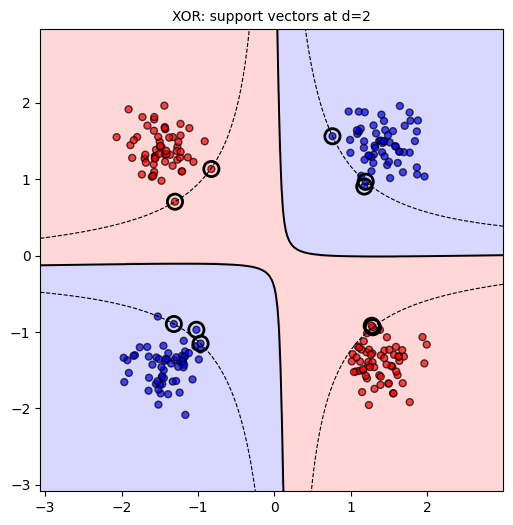

In [8]:
# Problem 4(d): support vectors at the minimum separating degree
d_min_xor = min(sep_degrees)
res_min = models_xor[d_min_xor]
print(f"Minimum separating degree: d = {d_min_xor}")
print(f"Number of support vectors: {res_min['n_support']}")

fig, ax = plt.subplots(figsize=(6, 6))
plot_support_vectors(ax, res_min['pipeline'], X_xor, y_xor,
                     title=f"XOR: support vectors at d={d_min_xor}")
plt.show()

---
## 3  Dataset 2: Interleaving Crescents

The data generator is provided.  **You write the fitting, plotting, and analysis code**,
following the workflow demonstrated in the XOR section.
You may call `fit_poly_svm`, `run_grid`, `plot_boundary_and_margin`, and `plot_support_vectors`.

### Problem 5 (Before fitting)

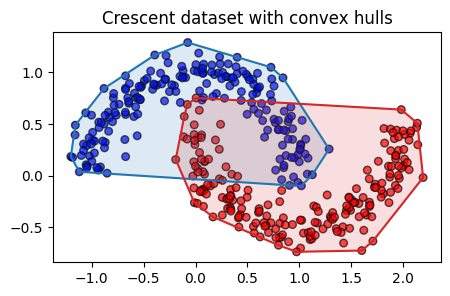

In [9]:
# Generate the crescent dataset
X_moon, y_moon = make_crescents(n_samples=400, noise=0.12, random_state=RNG)

fig, ax = plt.subplots(figsize=(5, 5))
plot_data(ax, X_moon, y_moon, title="Crescent dataset with convex hulls")
plot_convex_hulls(ax, X_moon, y_moon)
plt.show()
# Problem 5(a): display the dataset with convex hulls

*Problem 5(a)–(b): Write your predictions in your report before fitting.*

### Problem 6 (Fitting and observation)

Fit polynomial kernel SVMs with $c = 1$, degrees $d \in \{2, 3, 4, 5\}$,
and $C \in \{0.1, 1, 10\}$.

    degree     C  train_acc  cv_acc_mean
0        2   0.1     0.8750       0.8775
1        3   0.1     0.9450       0.9400
2        4   0.1     0.9825       0.9750
3        5   0.1     0.9925       0.9850
4        2   1.0     0.8900       0.8850
5        3   1.0     0.9925       0.9850
6        4   1.0     0.9950       0.9925
7        5   1.0     0.9925       0.9925
8        2  10.0     0.8950       0.8850
9        3  10.0     0.9925       0.9925
10       4  10.0     0.9950       0.9900
11       5  10.0     0.9975       0.9875


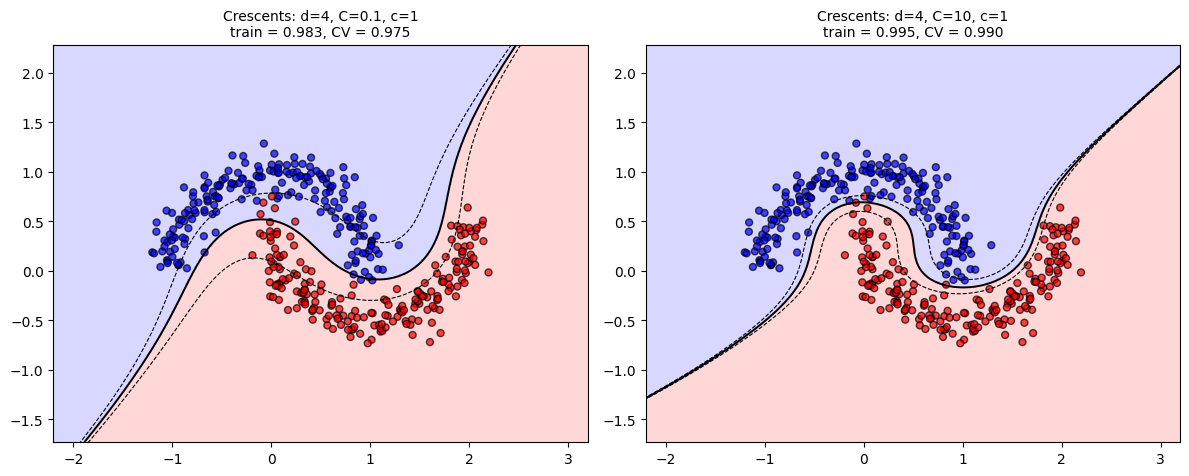

d=4, C=0.1
  support vectors: 83
  train acc: 0.9825
  CV acc: 0.9750000000000002
d=4, C=10
  support vectors: 16
  train acc: 0.995
  CV acc: 0.99


In [10]:
# Problem 6(a): table of training and CV accuracy for each (d, C)

degrees_crescent = [2, 3, 4, 5]
C_values = [0.1, 1, 10]

results_crescent = []

for Cval in C_values:
    for d in degrees_crescent:
        res = fit_poly_svm(X_moon, y_moon, degree=d, C=Cval, coef0=1.0)
        results_crescent.append({
            "degree": d,
            "C": Cval,
            "train_acc": res["train_acc"],
            "cv_acc_mean": res["cv_acc_mean"]
        })

crescent_table = pd.DataFrame(results_crescent)
print(crescent_table)

# Problem 6(b): side-by-side plots for two C values at the minimum separating degree

degree_min = 4
C_compare = [0.1, 10]

models_compare = {}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, Cval in zip(axes, C_compare):
    res = fit_poly_svm(X_moon, y_moon, degree=degree_min, C=Cval, coef0=1.0)
    models_compare[Cval] = res

    title = (
        f"Crescents: d={degree_min}, C={Cval}, c=1\n"
        f"train = {res['train_acc']:.3f}, CV = {res['cv_acc_mean']:.3f}"
    )

    plot_boundary_and_margin(ax, res["pipeline"], X_moon, y_moon, title=title)

plt.tight_layout()
plt.show()

for Cval in C_compare:
    clf = models_compare[Cval]["pipeline"].named_steps["svc"]
    print(f"d={degree_min}, C={Cval}")
    print("  support vectors:", len(clf.support_))
    print("  train acc:", models_compare[Cval]["train_acc"])
    print("  CV acc:", models_compare[Cval]["cv_acc_mean"])

In [11]:
# Problem 6(a) continued: Plot decision boundaries for all (d, C) combinations.
# A grid of subplots (rows = degrees, columns = C values) works well.
#
# Hint: see the XOR degree-sweep cell for the pattern.

# Your code here


In [12]:
# Problem 6(b): Side-by-side plots for C = 0.1 and C = 10 at the
# minimum separating degree, illustrating the effect of the soft margin.

# Your code here


In [13]:
# Problem 6(d): Compare support vector counts between XOR and crescents
# at their respective minimum separating degrees.

# Your code here


---
## 4  Dataset 3: Fragmented Clusters 

The data generator is provided. 
Follow the same workflow: display data, compute feature space dimensions,
fit models over a $(d, C)$ grid, produce an accuracy table and representative
plots, and analyze support vector counts. 
You may call `fit_poly_svm`, `run_grid`, `plot_boundary_and_margin`, and `plot_support_vectors`.

### Problem 7 (Before fitting)

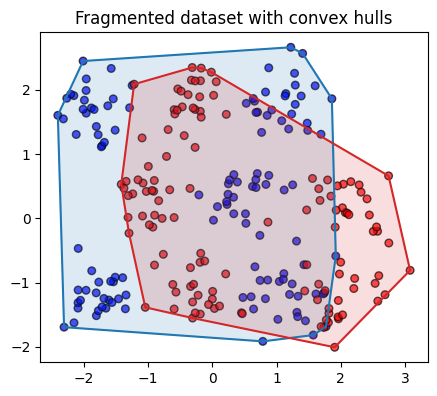

In [23]:
# Generate the fragmented cluster dataset
X_frag, y_frag = make_fragmented(n_per_cluster=25, random_state=42)
fig, ax = plt.subplots(figsize=(5, 5))
plot_data(ax, X_frag, y_frag, title="Fragmented dataset with convex hulls")
plot_convex_hulls(ax, X_frag, y_frag)
plt.show()
# Problem 7(a): display the dataset with convex hulls

In [25]:
# Problem 7(b): Compute feature space dimensions for d = 5, 8, 10 with c = 1.
#
# Hint: use n_monomials_degree_leq(d).

# Your code here

degrees = [5, 8, 10]

for d in degrees:
    dim = n_monomials_degree_leq(d)
    print(f"d = {d}: feature space dimension = {dim}")


d = 5: feature space dimension = 21
d = 8: feature space dimension = 45
d = 10: feature space dimension = 66


### Problem 8 (Fitting, observation, and diagnosis)

Fit polynomial kernel SVMs with $c = 1$, degrees $d \in \{3, 5, 8\}$,
and $C \in \{0.1, 10\}$.

In [32]:
# Problem 8(a): Accuracy table.

# Your code here
degrees_frag = [3, 5, 8]
C_values = [0.1, 10]

results_frag = []
models_frag = {}

for Cval in C_values:
    for d in degrees_frag:
        res = fit_poly_svm(X_frag, y_frag, degree=d, C=Cval, coef0=1.0)

        results_frag.append({
            "degree": d,
            "C": Cval,
            "train_acc": res["train_acc"],
            "cv_acc_mean": res["cv_acc_mean"],
            "SVC": len(res["pipeline"].named_steps["svc"].support_)
        })

        models_frag[(d, Cval)] = res

frag_table = pd.DataFrame(results_frag)
frag_table = frag_table.sort_values(["C", "degree"]).reset_index(drop=True)
print(frag_table)



   degree     C  train_acc  cv_acc_mean  SVC
0       3   0.1      0.784        0.784  189
1       5   0.1      0.928        0.904  124
2       8   0.1      0.948        0.924   66
3       3  10.0      0.908        0.880   77
4       5  10.0      0.956        0.932   44
5       8  10.0      0.964        0.900   40


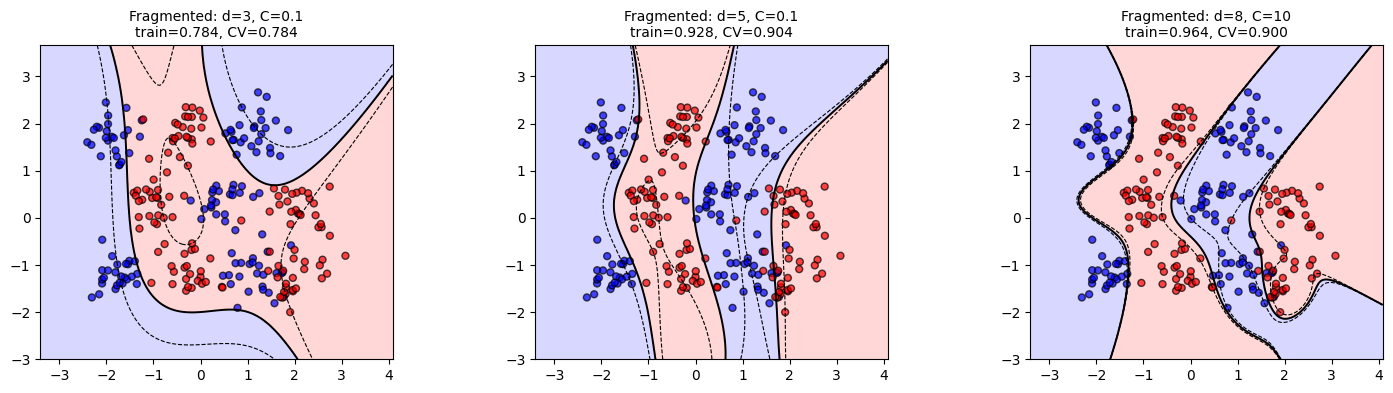

In [28]:
# Problem 8(a) continued: Representative decision boundary plots.
# You do not need to include every plot; choose the ones that
# best illustrate your conclusions.

# Your code here

representative_settings = [(3, 0.1), (5, .1), (8, 10)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (d, Cval) in zip(axes, representative_settings):
    res = models_frag[(d, Cval)]
    title = (
        f"Fragmented: d={d}, C={Cval}\n"
        f"train={res['train_acc']:.3f}, CV={res['cv_acc_mean']:.3f}"
    )
    plot_boundary_and_margin(ax, res["pipeline"], X_frag, y_frag, title=title)

plt.tight_layout()
plt.show()


In [18]:
# Problem 8(c): Plot the decision boundary at the best CV setting.

# Your code here


In [19]:
# Problem 8(d): Support vector counts across degrees.

# Your code here
